# Установка пакетов и загрузка данных для ноутбука

Для работы нам понадобится установить пакет `waymax` https://github.com/waymo-research/waymax


Waymax -- симулятор для исследования автономного вождения, базирующийся на `Waymo Open Motion Dataset` https://github.com/waymo-research/waymo-open-dataset

Для обучения сетки будем использовать
`Pytorch Lightning` https://lightning.ai/docs/pytorch/

Для запуска на GPU нужно сменить среду выполнения на Графический процессор

Устанавливаем пакеты:

In [1]:
# !pip install --upgrade pip
# !pip install git+https://github.com/waymo-research/waymax.git@main#egg=waymo-waymax
# !pip install pytorch-lightning==2.5.0

Необходимые для семинара данные и код лежат по ссылке https://storage.yandexcloud.net/ysda/ysda-small.zip

Cкачаем и распакуем

In [ ]:
# !curl https://storage.yandexcloud.net/ysda/ysda-small.zip
# !unzip ysda-small.zip

unzip:  cannot find or open ysda-small.zip, ysda-small.zip.zip or ysda-small.zip.ZIP.


In [ ]:
SEMINAR_PATH = '/content/ysda-small/motion-planning-seminal-data-small'

Копируем себе в локальное файловое пространство папки с кодом модели и полезными функциями

In [ ]:
import os
import shutil

if not os.path.exists('lib'):
    shutil.copytree(os.path.join(SEMINAR_PATH, 'lib'), 'lib')
else:
    print('"lib" folder already exists. If you want to rewrite lib by original folder, remove local "lib" manually')

Импортируем библиотеки

In [ ]:
%%capture

import os
from copy import deepcopy

import mediapy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import pytorch_lightning as pl
from pytorch_lightning.loggers import TensorBoardLogger

from waymax.config import DatasetConfig
from waymax import visualization
from waymax import datatypes

from lib.planning_model.model import PlanningModel
from lib.data_utils import WaymaxDataset, scenario_to_features_gt


# Будем обучаться на GPU
device = 'cuda'

# Данные

Посмотрим, что из себя представляют данные

In [ ]:
# Функция для рекурсивного обхода директорий
def list_files(startpath):
    for root, dirs, files in os.walk(startpath):
        level = root.replace(startpath, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print('{}{}/'.format(indent, os.path.basename(root)))
        subindent = ' ' * 4 * (level + 1)
        for f in files:
            print('{}{}'.format(subindent, f))

list_files(SEMINAR_PATH)

С помощью следующей функции генерируем конфиг для подгрузки датасета

In [ ]:
def get_data_config(split_name, seminar_path=SEMINAR_PATH):
    split_path = os.path.join(SEMINAR_PATH, 'data', split_name)

    obj_count = int(os.listdir(split_path)[0].rsplit('-')[-1])
    return DatasetConfig(
        path=os.path.join(split_path, f'{split_name}_tfexample.tfrecord@{obj_count}'),
        max_num_objects=24,
        batch_dims=[8],
        repeat=1,
        shuffle_buffer_size=64,
        deterministic=False,
        num_shards=1
    )

Создаем датасеты для разных сплитов

In [ ]:
train_dataset = WaymaxDataset(get_data_config('training'))
val_dataset = WaymaxDataset(get_data_config('validation'))

Данные в датасете хранятся как список наблюдений каждые 100мс, то есть с частотой 10Гц

In [ ]:
FEATURES_STEPS = 11  # Используем 11 тиков прошлого, включая текущий
FUTURE_STEPS = 30  # Предсказываем 30 тиков будущего

## Визуализация данных

Загрузим один батч, он же сценарий, состоит из нескольких сцен

In [ ]:
scenario = next(iter(train_dataset))
scenario.keys()

### Траектории агентов

In [ ]:
log_trajectory = scenario['log_trajectory']

Возьмем из сценария траекторию и посмотрим на её ключи и размерность


In [ ]:
log_trajectory.keys()

**x**,  **y**, **z** - координаты агентов \
**vel_x**, **vel_y** - скорость агентов \
**yaw** - направление(угол) \
**valid** - маска видимсоти агента \
**timestamp_micros** - временная сетка для агентов \
**length**, **width**, **height** - длина, ширина, высота агента

Давайте посмотрим на shape наших объектов внутри траектории

In [ ]:
for el in log_trajectory:
  print(f"{el} shape:".ljust(25),  str(log_trajectory[el].shape))

8 - размерность батча \
24 - количество агентов \
91 - количество таймстемпов с шагом 100мс из которых 11 относятся к истории, 80 -- таргет

Визуализируем нашу траекторию в координатах x, y

In [ ]:
import matplotlib.pyplot as plt


# Select a sample from the batch (first) dimension
batch_index = 0

# Select a specific agent from the second dimension
agent_index = 0

x_sample = log_trajectory['x'][batch_index, agent_index, :]
y_sample = log_trajectory['y'][batch_index, agent_index, :]


# Plot the first 11 points (history)
plt.plot(x_sample[:12], y_sample[:12], 'ro-', label='History')

# Plot the remaining 80 points (trajectory)
plt.plot(x_sample[11:], y_sample[11:], 'bo-', label='Trajectory')

# Add labels and legend
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Trajectory Plot')
plt.legend()

# Show the plot
plt.show()

Визуализируем модуль скорости

In [ ]:
vel_x = log_trajectory['vel_x'][batch_index, agent_index, :]
vel_y = log_trajectory['vel_y'][batch_index, agent_index, :]
vel = np.linalg.norm(np.stack([vel_x, vel_y], axis=-1), axis=-1)

# Plot the first 11 points (history)
plt.plot(np.arange(11), vel[:11], 'ro-', label='History')

# Plot the remaining 80 points (trajectory)
plt.plot(np.arange(11, 91), vel[11:], 'bo-', label='Trajectory')

# Add labels and legend
plt.xlabel('Timestep')
plt.ylabel('Velocity norm')
plt.title('Velocity plot')
plt.legend()
plt.show()

### Карта

In [ ]:
rg_points = scenario.roadgraph_points

**roadgraph_points** - структура содержащая в себе всю статическую информацию про дорогу и окружение

In [ ]:
rg_points.keys()

**x**, **y**, **z** - координаты в пространстве \
**dir_x**, **dir_y**, **dir_z** - параметры определяющие ориентацию объектов, например дорожных полос \
**type** - параметр определяющий что это за тип точки (линия, ребро, знак стоп, ...) \
**id** - поле определяющее уникальный идентификатор полосы, линия кончается, если она с чем-то пересекается или кончается карта.


In [ ]:
for el in rg_points.keys():
  print(f"{el} shape:".ljust(25),  rg_points[el].shape)

8 - размерность батча \
30000 - число точек карты

In [ ]:
batch_idx = 0
where_valid = rg_points.valid[batch_idx]
plt.figure(figsize=(10, 10))
plt.scatter(
    x = rg_points.x[batch_idx][where_valid],
    y = rg_points.y[batch_idx][where_valid],
    s=0.1,
    c = rg_points.types[batch_idx][where_valid]
)
plt.show()

### Светофоры

**log_traffic_lights** структура, которая содержит информацию, которая зависит от времени, о цвете и позиции светофора

In [ ]:
traffic_lights = scenario.log_traffic_light

In [ ]:
traffic_lights.keys()

**x**, **y** и **z** координаты светофора \
**state** определяет цвет светофора, который зажжен в этот момент \
**lane_ids** - id линии, которую регулирует этот светофор

In [ ]:
for el in traffic_lights.keys():
  print(f"{el} shape:".ljust(25),  traffic_lights[el].shape)

8 - размерность батча \
16 - число светофоров \
91 - число таймстемпов

### Данные об объектах

In [ ]:
metadata = scenario.object_metadata


**object_metadata** - структура хранящая информацию об объектах

In [ ]:
metadata.keys()

**object_types** - тип объекта (пешеход, автомобиль, велосипедист) \

**ids** - уникальный идентификатор каждого объекта \

**is_sdc** - атрибут определяющий является ли этот объект ego (самим беспилотным автомобилем) \

**is_modeled** - атрибует определяет, должен ли быть объект предсказан \

In [ ]:
metadata.is_sdc.shape

8 - размерность батча \
24 - число агентов

In [ ]:

%%capture
import numpy as np
from tqdm import tqdm
import dataclasses

from waymax import config as _config
from waymax import dataloader


### Отрисуем статичную сцену

In [ ]:
# Using logged trajectory
batch_idx = 0
img = visualization.plot_simulator_state(scenario, use_log_traj=True, batch_idx=batch_idx)
mediapy.show_image(img)

### А теперь сделаем видео этой сцены
Не пугайтесь если ячейка будет прогоняться несколько минут

In [ ]:
imgs = []

state = scenario
batch_idx = 0
for _ in range(scenario.remaining_timesteps[batch_idx]):
  state = datatypes.update_state_by_log(state, num_steps=1)
  imgs.append(visualization.plot_simulator_state(state, use_log_traj=True, batch_idx=batch_idx))

mediapy.show_video(imgs, fps=10)

### Вспомогательные функции для работы с данными

Нам понадобится функция `scenario_to_features_gt` для того, чтобы из сценария с несколькими сценами получить фичи и гт для обучения.

Она принимает на вход индекс(`features_first_timestamp`), начиная с которого берет `features_timestamps` таймстемпов в качестве фичей. Оставшиеся таймстемпы до конца сцены пойдут в таргет. Кроме того массивы становятся торч-тензорами и обрезается карта вокруг эго-агента.

In [ ]:
features, gt = scenario_to_features_gt(
    scenario,
    # с какого таймстемпа начинать формировать фичи
    # мы будем использовать при аугментациях сдвигом и при генерации в closed loop
    features_first_timestamp=0,
    # сколько элементов брать в фичи, в нашем случае всегда 11
    features_timestamps=FEATURES_STEPS,
    # сколько элементов брать в гт
    gt_timestamps=FUTURE_STEPS,
    # сколько токенов карты вокруг агента оставить
    map_points=256,
    # на каком девайсе создавать тензора
    device='cpu'
)

In [ ]:
features['log_trajectory']['x'].shape

In [ ]:
gt['log_trajectory']['x'].shape

# PlanTF

## Модель

Импортируем PlanTF модель

In [ ]:
from lib.planning_model.model import PlanningModel

Посмотрим, как пользоваться моделью

In [ ]:
# берем семпл из датасета
scenario = next(iter(train_dataset))
# бьем на фичи и таргет
features, gt = scenario_to_features_gt(scenario)
# инициализируем модельку
model = PlanningModel(future_steps=FUTURE_STEPS)
# делаем предсказание
pred = model(features)

Посмотрим на формат выходноых тензоров

In [ ]:
pred.keys()

trajectory - параметры предсказанных траекторий \
logits - логиты траекторий

In [ ]:
for k, v in pred['trajectory'].items():
    print(k, v.shape)

Траектория имеет параметры `x, y, yaw, vel_x, vel_y`

8 - размерность батча \
6 - число предсказанных мод \
30 - число таймстемпов в траектории, оно же FUTURE_STEPS

In [ ]:
pred['logits'].shape

Данный выход содержит логиты, отвечающие вероятностям мод

8 - размерность батча \
6 - число предсказанных мод

Функция для open loop визуализации модельки

In [ ]:
def visualize_model_open_loop(model, scenario, batch_idx = 0):
    imgs = []

    features, gt = scenario_to_features_gt(scenario, device=device)
    model.to(device)
    pred = model(features)
    state = scenario

    best_mode = pred['logits'].argmax(dim=-1)[batch_idx].detach().cpu().numpy()
    new_x = pred['trajectory']['x'][batch_idx, best_mode].detach().cpu().numpy()
    new_y = pred['trajectory']['y'][batch_idx, best_mode].detach().cpu().numpy()
    new_yaw = pred['trajectory']['yaw'][batch_idx, best_mode].detach().cpu().numpy()
    new_vel_x = pred['trajectory']['vel_x'][batch_idx, best_mode].detach().cpu().numpy()
    new_vel_y = pred['trajectory']['vel_y'][batch_idx, best_mode].detach().cpu().numpy()

    is_sdc = state.object_metadata.is_sdc[batch_idx]

    state.log_trajectory.x = state.log_trajectory.x.at[batch_idx, is_sdc, 11:11+FUTURE_STEPS].set(new_x)
    state.log_trajectory.y = state.log_trajectory.y.at[batch_idx, is_sdc, 11:11+FUTURE_STEPS].set(new_y)
    state.log_trajectory.yaw = state.log_trajectory.yaw.at[batch_idx, is_sdc, 11:11+FUTURE_STEPS].set(new_yaw)
    state.log_trajectory.vel_x = state.log_trajectory.vel_x.at[batch_idx, is_sdc, 11:11+FUTURE_STEPS].set(new_vel_x)
    state.log_trajectory.vel_y = state.log_trajectory.vel_y.at[batch_idx, is_sdc, 11:11+FUTURE_STEPS].set(new_vel_y)
    state.log_trajectory.valid = state.log_trajectory.valid.at[batch_idx, is_sdc, 11+FUTURE_STEPS:].set(np.zeros(80-FUTURE_STEPS, dtype=bool))


    for _ in range(FUTURE_STEPS):
        state = datatypes.update_state_by_log(state, num_steps=1)
        imgs.append(visualization.plot_simulator_state(state, use_log_traj=True, batch_idx=batch_idx))

    mediapy.show_video(imgs, fps=10)

Посмотрим на предсказания случайной модели

In [ ]:
visualize_model_open_loop(model, scenario)

## Обучение

Класс `PlannerModule` нужен для тренировки с помощью Pytorch Lightning, он содержит опеределние методов, необходимых для обучения модели

In [ ]:
class PlannerModule(pl.LightningModule):
    """
    Module with methods for model training
    """
    def __init__(
        self,
        model,
        loss_components_function,
        metrics_function,
        training_shift_random_generator=lambda : 0,
        lr=5e-4
    ):
        """
        Args:
          model: model to train
          loss_components_function:
            function that takes (pred, gt) and return dict of losses
          metrics_function:
            function that takes (pred, gt) and return dict of metrics
          training_shift_random_generator:
            function that return shift for features/gt split
            it allow us to augment dataset and get more diverse scenarios
        """
        super().__init__()
        self.model = model
        self.loss_components_function = loss_components_function
        self.metrics_function = metrics_function
        self.training_shift_random_generator = training_shift_random_generator
        self.lr = lr

    # Вспомогательный метод для логгирования лоссов
    def log_loss(self, split_name, loss, loss_components, batch_size):
        """
        Log loss to tensorboard

        Args:
          split_name: train/val
          loss: step loss
          loss_components: dict of step loss components
          batch_size: batch_size
        """
        self.log(
            f'{split_name}/epoch/loss/loss',
            loss.detach().cpu().item(),
            batch_size=batch_size,
            on_epoch=True,
            on_step=False
        )
        for k, v in loss_components.items():
            self.log(
                f'{split_name}/epoch/loss/{k}',
                v.detach().cpu().item(),
                batch_size=batch_size,
                on_epoch=True,
                on_step=False
            )

    # Вспомогательный метод для логгирования метрик
    def log_metrics(self, split_name, metrics, batch_size):
        """
        Log metrics to tensorboard

        Args:
          split_name: train/val
          metrics: dict of step metrics
          batch_size: batch_size
        """
        for k, v in metrics.items():
            self.log(
                f'{split_name}/epoch/{k}',
                v.detach().cpu().item(),
                batch_size=batch_size,
                on_epoch=True,
                on_step=False
            )

    # Шаг применения модели
    def step(self, scenario, shift=0):
        """
        Make model step

        Args:
          scenario: train/val
          metrics: dict of step metrics
          batch_size: batch_size

        Returns:
          (
            pred,            # model output
            gt,              # target
            loss,            # loss value
            loss_components  # loss components dict
          )
        """

        # split scenario to features and gt
        features, gt = scenario_to_features_gt(
            scenario,
            features_first_timestamp=shift,
            device=self.device)
        # apply model
        pred = self.model(features)
        # compute losses
        loss_components = self.loss_components_function(pred, gt)
        loss = sum(loss_components[key] for key in loss_components.keys())
        return pred, gt, loss, loss_components

    # Шаг валидации
    @torch.no_grad
    def validation_step(self, scenario, batch_idx):
        """
        Make validation step

        Args:
          scenario: train/val
          batch_idx: number of step

        Returns:
          loss
        """
        pred, gt, loss, loss_components = self.step(scenario)
        self.log_loss(
            'val', loss, loss_components,
            batch_size=scenario['log_trajectory']['x'].shape[0],
        )
        self.log_metrics(
            'val', self.metrics_function(pred, gt),
            batch_size=scenario['log_trajectory']['x'].shape[0],)

        return loss

    # Шаг обучения
    def training_step(self, scenario, batch_idx):
        """
        Make training step

        Args:
          scenario: train/val
          batch_idx: number of step

        Returns:
          loss
        """
        pred, gt, loss, loss_components = self.step(scenario, shift=self.training_shift_random_generator())
        self.log_loss(
            'train', loss, loss_components,
            batch_size=scenario['log_trajectory']['x'].shape[0],
        )
        return loss

    # Создание оптимизатора
    def configure_optimizers(self):
        """
        Create optimizer

        Returns:
          optimizer
        """
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)
        return optimizer

### Бейзлайн

В бейзлайне будем тренировать только одну фиксированную моду с ade в качестве лосса

$$ADE=\frac{\sum\limits_{t=1}^{T} ||pred_t - target_t||_2}{T}$$

$$minADE=\min_{mode} ADE(pred_{mode}, target)$$

$$best = \arg\max\limits_{mode}(logit)$$
$$top1ADE=ADE(pred_{best}, target)$$


In [ ]:
def extract_ego_xy_gt(gt):
    """
    Make x, y target for ego

    Args:
      gt: target

    Returns:
      ego_xy_gt: target for ego x, y
    """
    return torch.stack(
        [
            gt['log_trajectory']['x'][gt['object_metadata']['is_sdc']],
            gt['log_trajectory']['y'][gt['object_metadata']['is_sdc']],
        ],
        dim=-1
    )


def ade_one_component_loss(pred, gt):
    """
    Compute loss as ADE of first mode

    Args:
      pred: prediction
      gt: target

    Returns:
      ade_loss: dict with loss
    """
    ego_xy_gt = extract_ego_xy_gt(gt)

    # force to take first mode
    ego_xy_first_mode_pred = torch.stack(
        [
            pred['trajectory']['x'][:, 0, :],
            pred['trajectory']['y'][:, 0, :],
        ],
        axis=-1
    )
    return {
        'ade_loss': torch.norm(ego_xy_gt - ego_xy_first_mode_pred, dim=-1).mean()
    }

Запускаем тензорборд

In [ ]:
%reload_ext tensorboard
%tensorboard --logdir=tb_logs/

Инициализируем модуль и тренера

In [ ]:
model = PlanningModel(future_steps=FUTURE_STEPS)

planner = PlannerModule(
    model=model,
    loss_components_function=ade_one_component_loss,
    metrics_function=lambda x, y : {},
    training_shift_random_generator=lambda : np.random.randint(0, 80 - FUTURE_STEPS + 1),
    lr=5e-4
)
planner = planner.to(device)
logger = TensorBoardLogger("tb_logs", name="my_model")

trainer = pl.Trainer(logger=logger, log_every_n_steps=1, gradient_clip_val=0.5, check_val_every_n_epoch=5)

Запускаем обучение

In [ ]:
trainer.fit(model=planner, train_dataloaders=train_dataset, val_dataloaders=val_dataset)

Можем визуализировать выход

In [ ]:
visualize_model_open_loop(planner.model, scenario)

### Задание

В примере выше есть 2 недостатка, которые Вам предлагается исправить
- Сделать нормализацию данных на входе сетки, то есть перевести все координаты в систему координат эго
- Использовать все 6 мод и мультимодальный лосс

Далее следуют ячейки с пропущенным кодом, реализуйте соответствующие функции для обучения более классной модельки

В этой ячейке реализуйте функции для поворота и сдвига координат

In [ ]:
def rotate(x, y, sin_yaw, cos_yaw):
    """
    Rotate x and y by yaw

    Args:
      x: torch.Tensor [batch_size, ...]
      y: torch.Tensor [batch_size, ...]
      sin_yaw: torch.Tensor [batch_size]
      cos_yaw: torch.Tensor [batch_size]

    Returns:
      rotated_x, rotated_y
    """
    assert x.shape == y.shape
    assert cos_yaw.shape == sin_yaw.shape
    assert len(cos_yaw.shape) == 1
    assert cos_yaw.shape[0] == x.shape[0]

    # torch needs same shapes len for computation
    # we need to reshape inputs and save original shape
    orig_shape = x.shape

    # make shape [bs, num_all_points]
    x = x.reshape(orig_shape[0], -1)
    y = y.reshape(orig_shape[0], -1)

    # make shape [bs, 1]
    cos_yaw = cos_yaw.reshape(-1, 1)
    sin_yaw = sin_yaw.reshape(-1, 1)

    # rotate by yaw
    new_x = # YOUR CODE HERE
    new_y = # YOUR CODE HERE

    return new_x.reshape(orig_shape), new_y.reshape(orig_shape)


def shift(x, y, shift_x, shift_y):
    """
    Shift x and y by shift_x and shift_y

    Args:
      x: torch.Tensor [batch_size, ...]
      y: torch.Tensor [batch_size, ...]
      shift_x: torch.Tensor [batch_size]
      shift_y: torch.Tensor [batch_size]

    Returns:
      shifted_x, shifted_y
    """
    assert x.shape == y.shape
    assert shift_x.shape == shift_y.shape
    assert len(shift_x.shape) == 1
    assert shift_x.shape[0] == x.shape[0]

    # torch needs same shapes len for computation
    # we need to reshape inputs and save original shape
    orig_shape = x.shape

    # make shape [bs, num_all_points]
    x = x.reshape(orig_shape[0], -1)
    y = y.reshape(orig_shape[0], -1)

    # make shape [bs, 1]
    shift_x = shift_x.reshape(-1, 1)
    shift_y = shift_y.reshape(-1, 1)

    # shift
    new_x = # YOUR CODE HERE
    new_y = # YOUR CODE HERE

    return new_x.reshape(orig_shape), new_y.reshape(orig_shape)

Тест

In [ ]:
def shift_rotation_test():
    x = torch.tensor([[[1.2]], [[2.3]], [[3.4]]])
    y = torch.tensor([[[0.7]], [[1.8]], [[9.2]]])
    shift_x = torch.tensor([2.5, 1.3, -0.25])
    shift_y = torch.tensor([-5.3, -3.1, 2.5])
    yaw = torch.tensor([1, 2, 3])

    shifted_x, shifted_y = shift(x, y, shift_x, shift_y)
    assert torch.all(torch.isclose(shifted_x, torch.tensor([[[3.7]], [[3.6]], [[3.15]]])))
    assert torch.all(torch.isclose(shifted_y, torch.tensor([[[-4.6]], [[-1.3]], [[11.7]]])))

    rotated_x, rotated_y = rotate(x, y, torch.sin(yaw), torch.cos(yaw))

    assert torch.all(torch.isclose(rotated_x, torch.tensor([[[0.0593]], [[-2.5939]], [[-4.6643]]]), rtol=1e-03, atol=1e-03))
    assert torch.all(torch.isclose(rotated_y, torch.tensor([[[1.3880]], [[1.3423]], [[-8.6281]]]), rtol=1e-03, atol=1e-03))

    print('All tests passed')


shift_rotation_test()

Класс ниже нужен для того, чтобы в модель пришла сцена, центрированная относительно эго. Для этого нужно взять в качестве `reference_point` координаты и направление эго и применить сдвиг с поворотом к координатам, скорости, углу

Заполните пропуски в коде в реализации класса

In [ ]:
class NormalizeSceneWrapper(nn.Module):
    """
    Wrap model with normalize_features and denormalize_predictions functions
    """

    def __init__(self, model):
        """
        Args:
          model: model to wrap
        """
        super().__init__()
        self.model = model


    def normalize_features(
        self,
        features,
        ref_point_x,
        ref_point_y,
        ref_point_yaw
      ):
        """
        Args:
          features: model features
          ref_point_x: torch.Tensor [batch_size]
          ref_point_y: torch.Tensor [batch_size]
          ref_point_yaw: torch.Tensor [batch_size]

        Returns:
          norm_features: features after normalization
        """
        norm_features = deepcopy(features)

        # Find sin and cos for normalization rotation transform
        rotate_cos = # YOUR CODE HERE
        rotate_sin = # YOUR CODE HERE

        for key in ['log_trajectory', 'log_traffic_light', 'roadgraph_points']:
            # apply transforms to coordinates (features[key]['x'], features[key]['y'])

            # YOUR CODE HERE
            new_x, new_y = # YOUR CODE HERE

            norm_features[key]['x'] = new_x
            norm_features[key]['y'] = new_y

        for key, prefix in [['log_trajectory', 'vel'], ['roadgraph_points', 'dir']]:
            # apply transforms to vectors and directions
            # (features[key][f'{prefix}_x'], features[key][f'{prefix}_y'])

            new_x, new_y = # YOUR CODE HERE

            norm_features[key][f'{prefix}_x'] = new_x
            norm_features[key][f'{prefix}_y'] = new_y

        # apply transform to yaw

        norm_features['log_trajectory']['yaw'] = # YOUR CODE HERE

        return norm_features


    def denormalize_predictions(
          self,
          pred,
          ref_point_x,
          ref_point_y,
          ref_point_yaw
        ):
        """
        Args:
          pred: model prediction
          ref_point_x: torch.Tensor [batch_size]
          ref_point_y: torch.Tensor [batch_size]
          ref_point_yaw: torch.Tensor [batch_size]

        Returns:
          norm_pred: pred after normalization
        """

        # Find sin and cos for denormalization rotation transform
        rotate_cos = # YOUR CODE HERE
        rotate_sin = # YOUR CODE HERE

        old_shape = pred['trajectory']['x'].shape

        pred_ego_x = pred['trajectory']['x']
        pred_ego_y = pred['trajectory']['y']
        pred_ego_yaw = pred['trajectory']['yaw']
        pred_ego_vel_x = pred['trajectory']['vel_x']
        pred_ego_vel_y = pred['trajectory']['vel_y']

        # apply transform to pred_ego_x, pred_ego_y

        # YOUR CODE HERE
        new_pred_ego_x, new_pred_ego_y = # YOUR CODE HERE

        # apply transform to pred_ego_vel_x, pred_ego_vel_y

        new_pred_ego_vel_x, new_pred_ego_vel_y = # YOUR CODE HERE

        # apply transform to yaw

        new_pred_ego_yaw = # YOUR CODE HERE

        pred['trajectory'] = {
            'x': new_pred_ego_x.reshape(*old_shape),
            'y': new_pred_ego_y.reshape(*old_shape),
            'yaw': new_pred_ego_yaw.reshape(*old_shape),
            'vel_x': new_pred_ego_vel_x.reshape(*old_shape),
            'vel_y': new_pred_ego_vel_y.reshape(*old_shape),
        }

        return pred

    def forward(self, features):
        """
        Normalize features, run model and denormalize predictions

        Args:
          features: model prediction

        Returns:
          pred: pred of model
        """
        is_sdc = features['object_metadata']['is_sdc']
        # take last ego state for reference point from features['log_trajectory']
        ref_point_x = # YOUR CODE HERE
        ref_point_y = # YOUR CODE HERE
        ref_point_yaw = # YOUR CODE HERE

        new_features = self.normalize_features(
            features,
            ref_point_x,
            ref_point_y,
            ref_point_yaw
        )

        pred = self.model(new_features)

        pred = self.denormalize_predictions(
            pred,
            ref_point_x,
            ref_point_y,
            ref_point_yaw
          )

        return pred

Тест

In [ ]:
def normalization_test():
    normalizer = NormalizeSceneWrapper(None)

    x = torch.tensor([[[2, 3]], [[4, 5]]])
    y = torch.tensor([[[0, -2]], [[-5, 7]]])
    yaw = torch.tensor([[[-0.1, 4.3]], [[0.1, 7.8]]])

    ref_x = torch.tensor([1.5, -2])
    ref_y = torch.tensor([-1.5, 0])
    ref_yaw = torch.tensor([-2, 1])

    features = {
        k: {'x': x, 'y': y}
        for k in ['log_trajectory', 'log_traffic_light', 'roadgraph_points']
    }
    features['roadgraph_points']['dir_x'] = x
    features['roadgraph_points']['dir_y'] = y

    features['log_trajectory']['vel_x'] = x
    features['log_trajectory']['vel_y'] = y

    features['log_trajectory']['yaw'] = yaw

    res = normalizer.normalize_features(features, ref_x, ref_y, ref_yaw)

    res_x_1 = torch.tensor([[[-1.5720, -0.1696]], [[-0.9655,  9.6724]]])
    res_y_1 = torch.tensor([[[-0.1696,  1.5720]], [[-7.7503, -2.1082]]])

    res_x_2 = torch.tensor([[[-0.8323,  0.5702]], [[-2.0461,  8.5918]]])
    res_y_2 = torch.tensor([[[ 1.8186,  3.5602]], [[-6.0674, -0.4252]]])

    for k in ['log_trajectory', 'log_traffic_light', 'roadgraph_points']:
        assert torch.all(
            torch.isclose(res[k]['x'], res_x_1, rtol=1e-03, atol=1e-03)
        )
        assert torch.all(
            torch.isclose(res[k]['y'], res_y_1, rtol=1e-03, atol=1e-03)
        )

    assert torch.all(
        torch.isclose(res['roadgraph_points']['dir_x'], res_x_2, rtol=1e-03, atol=1e-03)
    )
    assert torch.all(
        torch.isclose(res['roadgraph_points']['dir_y'], res_y_2, rtol=1e-03, atol=1e-03)
    )
    assert torch.all(
        torch.isclose(res['log_trajectory']['vel_x'], res_x_2, rtol=1e-03, atol=1e-03)
    )
    assert torch.all(
        torch.isclose(res['log_trajectory']['vel_y'], res_y_2, rtol=1e-03, atol=1e-03)
    )
    assert torch.all(
        torch.isclose(res['log_trajectory']['yaw'], torch.tensor([[[ 1.9000,  6.3000]], [[-0.9000,  6.8000]]]), rtol=1e-03, atol=1e-03)
    )


    pred = {
        'trajectory': {
            'x': x,
            'y': y,
            'yaw': yaw,
            'vel_x': x,
            'vel_y': y
        }
    }

    res = normalizer.denormalize_predictions(pred, ref_x, ref_y, ref_yaw)

    trajectory = torch.stack(
        [
            res['trajectory']['x'],
            res['trajectory']['y'],
            res['trajectory']['yaw'],
            res['trajectory']['vel_x'],
            res['trajectory']['vel_y']
        ],
        axis=-1
    )
    assert torch.all(
        torch.isclose(
            trajectory,
            torch.tensor(
                [[[[ 0.6677, -3.3186, -2.1000, -0.8323, -1.8186],
                 [-1.5670, -3.3956,  2.3000, -3.0670, -1.8956]]],
                 [[[ 4.3686,  0.6644,  1.1000,  6.3686,  0.6644],
                 [-5.1888,  7.9895,  8.8000, -3.1888,  7.9895]]]]
            ),
            rtol=1e-03,
            atol=1e-03
        )
    )

    print('All tests passed')


normalization_test()

Далее содержатся функции с мультимодальным лоссом, заполните пропуски

In [ ]:
def extract_ego_gt_for_reg_loss(gt):
    """
    Make target for ego reg loss

    Args:
      gt: target

    Returns:
      ego_xy_gt: target for ego x, y, sin_yaw, cos_yaw, vel_x, vel_y
    """
    return torch.stack(
        [
            gt['log_trajectory']['x'][gt['object_metadata']['is_sdc']],
            gt['log_trajectory']['y'][gt['object_metadata']['is_sdc']],
            torch.sin(gt['log_trajectory']['yaw'][gt['object_metadata']['is_sdc']]),
            torch.cos(gt['log_trajectory']['yaw'][gt['object_metadata']['is_sdc']]),
            gt['log_trajectory']['vel_x'][gt['object_metadata']['is_sdc']],
            gt['log_trajectory']['vel_y'][gt['object_metadata']['is_sdc']],
        ],
        dim=-1
    )

def extract_pred_components_for_reg_loss(ego_pred_traj):
    """
    Make pred for ego reg loss

    Args:
      ego_pred_traj: pred

    Returns:
      ego_pred_traj: pred for ego x, y, sin_yaw, cos_yaw, vel_x, vel_y
    """
    return torch.stack(
        [
            ego_pred_traj['x'],
            ego_pred_traj['y'],
            torch.sin(ego_pred_traj['yaw']),
            torch.cos(ego_pred_traj['yaw']),
            ego_pred_traj['vel_x'],
            ego_pred_traj['vel_y'],
        ],
        dim=-1
    )

def extract_pred_xy(ego_pred_traj):
    """
    Make pred for ego reg loss

    Args:
      ego_pred_traj: pred

    Returns:
      ego_pred_traj: pred for ego x, y
    """
    return torch.stack(
        [
            ego_pred_traj['x'],
            ego_pred_traj['y'],
        ],
        dim=-1
    )


def ego_loss_components(pred, gt):
    """
    Compute ego loss components for regression and classification task

    Args:
      pred: prediction
      gt: target

    Returns:
      losses: dict with cls_loss and reg_loss
    """
    ego_pred_components = extract_pred_components_for_reg_loss(pred['trajectory'])
    ego_pred_xy = extract_pred_xy(pred['trajectory'])

    ego_xy_gt = extract_ego_xy_gt(gt)[:, None, :]

    # compute ade per mode
    ade_per_mode = # YOUR CODE HERE
    # select best mode
    best_mode = # YOUR CODE HERE

    best_pred_traj = ego_pred_components[
        torch.arange(ego_pred_components.shape[0], device=ego_xy_gt.device),
        best_mode
    ]
    ego_gt = extract_ego_gt_for_reg_loss(gt)


    reg_loss = torch.norm(best_pred_traj - ego_gt, dim=-1).mean()
    # compute cross entropy between logits and best_mode
    cls_loss = # YOUR CODE HERE

    return {
        'reg_loss': reg_loss,
        'cls_loss': cls_loss
    }

Тест

In [ ]:
def get_fake_pred_gt():
    pred = {
        'trajectory': {
            'x': torch.tensor([[[0.1], [-0.7]]]),
            'y': torch.tensor([[[0.8], [13]]]),
            'yaw': torch.tensor([[[2], [-1]]]),
            'vel_x': torch.tensor([[[3], [4]]]),
            'vel_y': torch.tensor([[[5], [8]]])
        },
        'logits': torch.tensor(
            [[1., 2]]
        )
    }
    gt = {
        'log_trajectory': {
            'x': torch.tensor([[[7, -9.]]]),
            'y': torch.tensor([[[2, 8.]]]),
            'yaw': torch.tensor([[[1, -1.]]]),
            'vel_x': torch.tensor([[[3, -4.]]]),
            'vel_y': torch.tensor([[[2, 5.]]]),

        },
        'object_metadata': {
            'is_sdc': torch.tensor([[True]])
        }
    }
    return pred, gt


def loss_test():
    loss = ego_loss_components(*get_fake_pred_gt())
    assert torch.isclose(loss['reg_loss'], torch.tensor(10.6865), atol=1e-3, rtol=1e-3)
    assert torch.isclose(loss['cls_loss'], torch.tensor(1.3133), atol=1e-3, rtol=1e-3)

    print('All tests passed')

loss_test()

In [ ]:
def min_ade(pred, gt):
    """
    Compute min ade per mode, mean per batch

    Args:
      pred: prediction
      gt: target

    Returns:
      min_ade: value of min ade metric
    """
    ego_xy_gt = extract_ego_xy_gt(gt)[:, None, :]
    ego_pred_xy = extract_pred_xy(pred['trajectory'])

    # compute ade per mode
    ade_per_mode = # YOUR CODE HERE
    # compute ade of closest mode
    return # YOUR CODE HERE


def top1_ade(pred, gt):
    """
    Compute ade of top1 mode, mean per batch

    Args:
      pred: prediction
      gt: target

    Returns:
      top1_ade: value of top1 ade metric
    """
    ego_xy_gt = extract_ego_xy_gt(gt)[:, None, :]
    ego_pred_xy = extract_pred_xy(pred['trajectory'])

    # compute ade per mode
    ade_per_mode = # YOUR CODE HERE
    # select best mode
    best_mode = # YOUR CODE HERE
    top1_ade = ade_per_mode[
        torch.arange(ade_per_mode.shape[0], device=ego_xy_gt.device),
        best_mode
    ]
    return top1_ade.mean()


def plantf_metrics(pred, gt):
    """
    Compute plantf metrics

    Args:
      pred: prediction
      gt: target

    Returns:
      metrics: dict with plantf metrics
    """
    return {
        'min_ade': min_ade(pred, gt),
        'top1_ade': top1_ade(pred, gt),
    }

Тест

In [ ]:
def metrics_test():
    metrics = plantf_metrics(*get_fake_pred_gt())

    assert torch.isclose(metrics['min_ade'], torch.tensor(9.3037), atol=1e-3, rtol=1e-3)
    assert torch.isclose(metrics['top1_ade'], torch.tensor(11.5584), atol=1e-3, rtol=1e-3)

    print('All tests passed')

metrics_test()

Тензорборд

In [ ]:
%reload_ext tensorboard
%tensorboard --logdir=tb_logs/

Модуль и тренер для обернутой модели с новым лоссом

In [ ]:
model = NormalizeSceneWrapper(PlanningModel(future_steps=FUTURE_STEPS))

planner = PlannerModule(
    model=model,
    loss_components_function=ego_loss_components,
    metrics_function=plantf_metrics,
    training_shift_random_generator=lambda : np.random.randint(0, 80 - FUTURE_STEPS + 1),
    lr=5e-4
)
planner = planner.to(device)
logger = TensorBoardLogger("tb_logs", name="my_model")

trainer = pl.Trainer(logger=logger, log_every_n_steps=1, gradient_clip_val=0.5, check_val_every_n_epoch=5)

Запускаем обучение. Предполагается, что модель выбьет `min_ade <= 1` за 15 минут. При достижении такой метрики можно переходить к следующему заданию

In [ ]:
trainer.fit(model=planner, train_dataloaders=train_dataset, val_dataloaders=val_dataset)

Визуализируем результат

In [ ]:
visualize_model_open_loop(planner.model, scenario, batch_idx=1)

# Fine-tuning with Reinforcement Learning

In [ ]:
from waymax import config as _config
from waymax import dataloader
from waymax import datatypes
from waymax import dynamics
from waymax import env as _env
from waymax import agents
from waymax import visualization
from waymax.agents import SimAgentActor, WaymaxActorOutput

from torch.distributions import Categorical

import jax
from jax import numpy as jnp
from jax import random

import chex

import dataclasses

from typing import Any, Optional, Callable, Sequence
import mediapy

## REINFORCE Algorithm

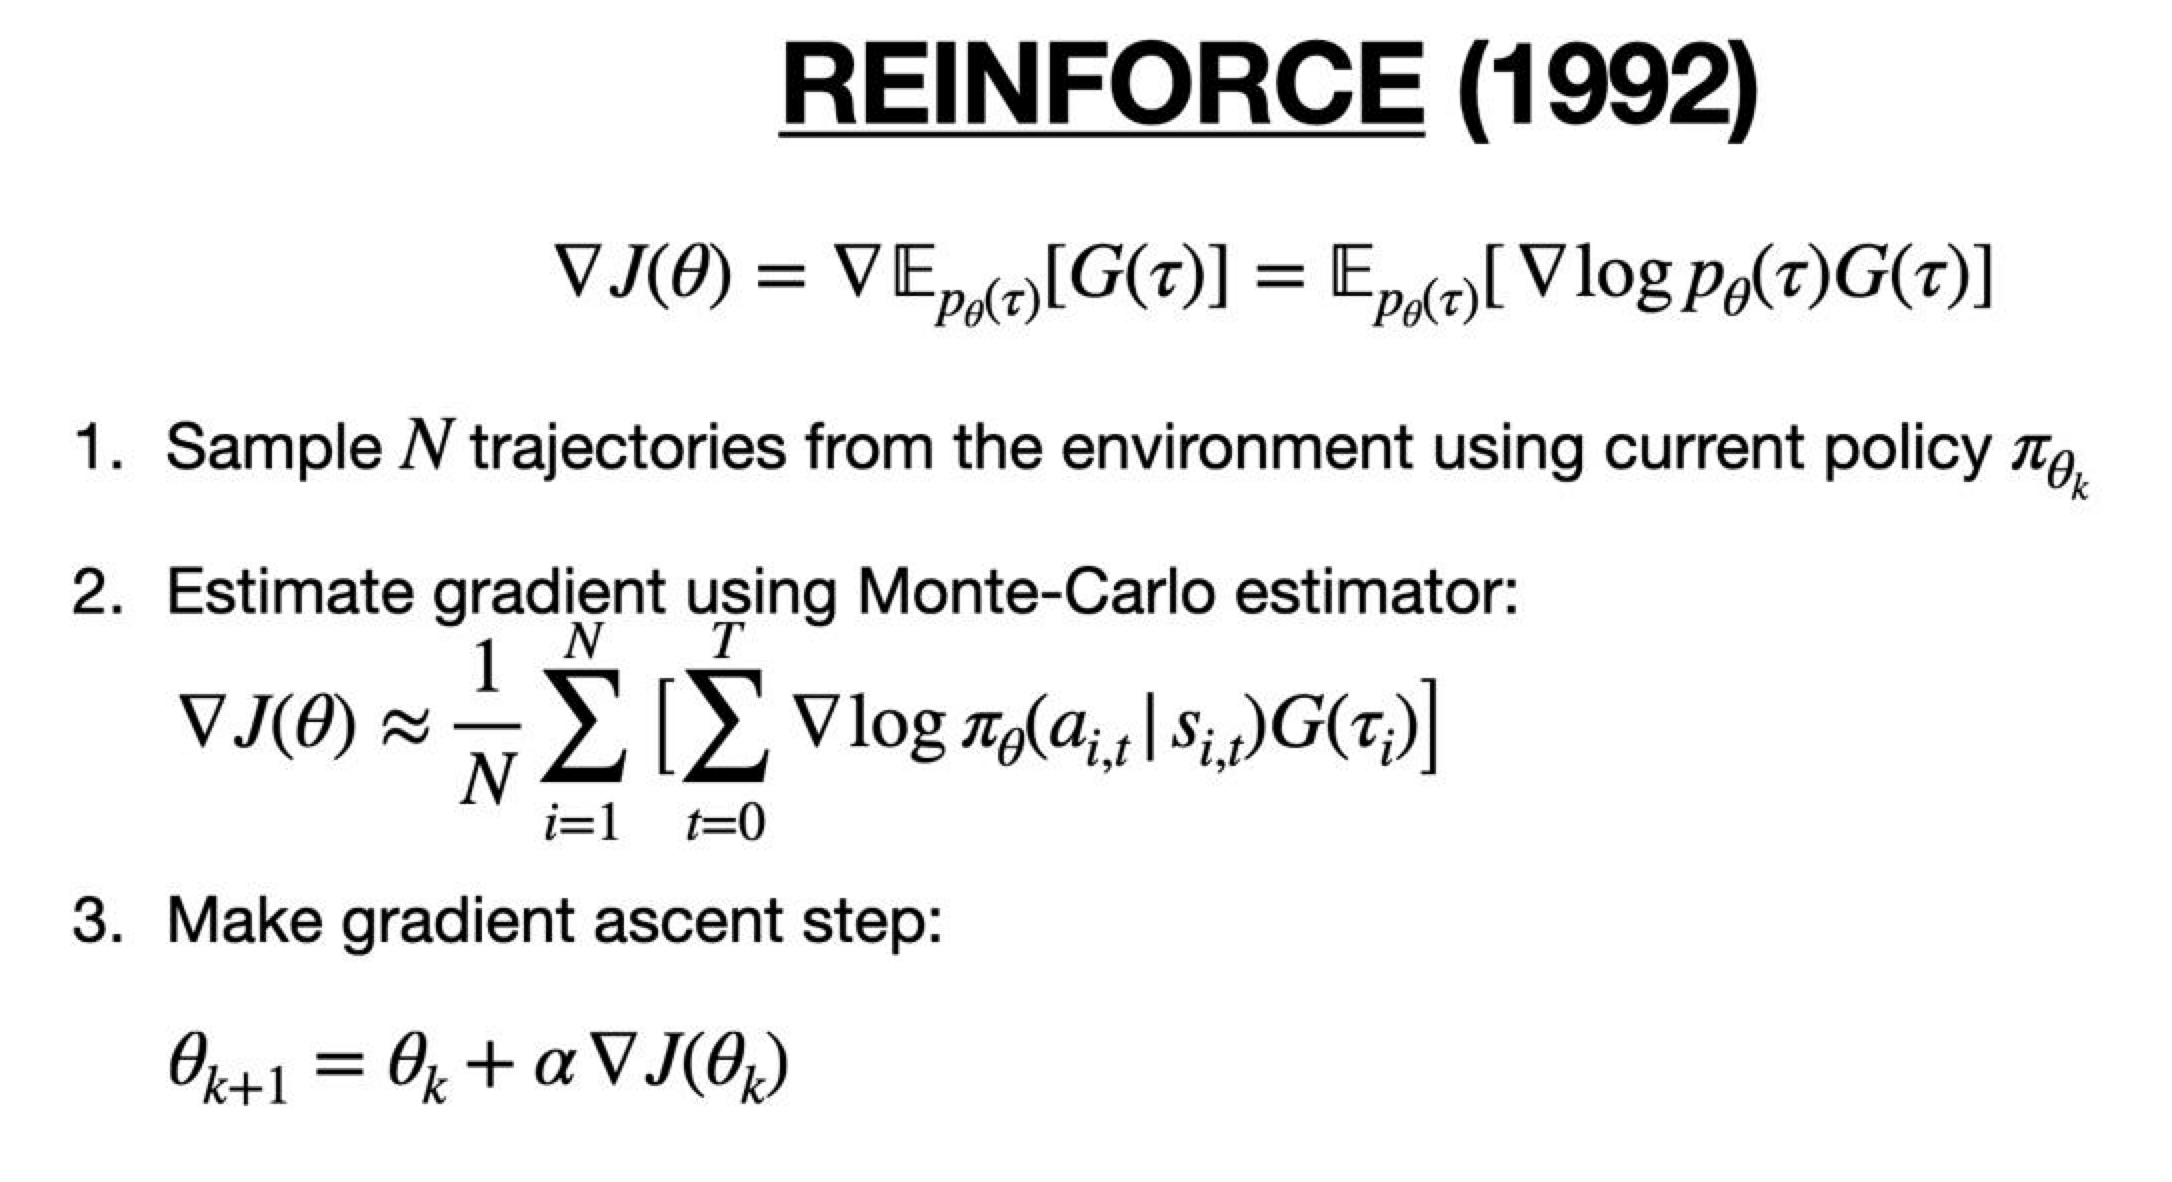

## Initializing the ego-agent as RL agent

**Класс EgoAgent** является реализацией агента, который управляет эго-объектом в симуляции. Он наследует от класса SimAgentActor и расширяет его функциональность для работы с моделью машинного обучения, которая предсказывает действия агента.


1. Метод update_trajectory обновляет траекторию агента на основе предсказанного действия. Преобразует действие, полученное от модели, в формат, понятный симуляции.


2. Метод select_action является ключевым в классе EgoAgent. Он отвечает за выбор действия на основе текущей политики и возвращает логарифмические вероятности действий, которые используются для вычисления потерь в алгоритме REINFORCE.

  **Как работает этот метод?**

    Предсказывает действия и их вероятности с помощью модели.
    Выбирает действие случайным образом, но с учетом вероятностей.
    Возвращает выбранное действие и данные, необходимые для обучения агента.

### Задание 0.1

Заполните пропуски в коде

In [ ]:
ActorState = datatypes.PyTree
Params = datatypes.PyTree
Action = datatypes.PyTree


@chex.dataclass(frozen=True)
class RLActorOutput(agents.WaymaxActorOutput):
    """Output of the RL actor, extending WaymaxActorOutput with logits.

    Attributes:
        actor_state: Internal state for whatever the agent needs to keep as its
          state. This can be recurrent embeddings or accounting information.
        action: Action of shape (..., num_objects) predicted by the RL actor.
        is_controlled: A binary indicator of shape (..., num_objects) representing
          which objects are controlled by the actor.
        logits: Logits output by the RL actor, typically representing the raw
          output of a policy network before applying a softmax or other transformation.
    """

    logits: Optional[jax.Array]

class EgoAgent(SimAgentActor):
    def __init__(self,  model, is_controlled_func: Optional[Callable[[datatypes.SimulatorState], jax.Array]] = None):
        super().__init__(is_controlled_func=is_controlled_func)

        self.model = model


    def update_trajectory(
        self, action: datatypes.SimulatorState
    ) -> datatypes.TrajectoryUpdate:
        """Updates the trajectory for all simulated agents."""

        next_action_jax = jax.tree_util.tree_map(lambda x: jnp.array(x.cpu().detach().numpy()), action)
        x, y, yaw, vel_x, vel_y = jnp.split(next_action_jax, 5, axis=-1)

        valid = jnp.bool_(jnp.ones_like(x))  # for the ego agent, we assume that it is always valid (present on the scene)

        return datatypes.TrajectoryUpdate(x=x, y=y, yaw=yaw, vel_x=vel_x, vel_y=vel_y, valid=valid)

    def select_action(
        self,
        params: Params,
        state: datatypes.SimulatorState,
        actor_state: Any,
        rng: jax.Array,
    ) -> agents.WaymaxActorOutput:
        """Selects action and updates trajectory given the current simulator state."""

        del actor_state, rng  # Not used
        timestep = params['timestep']
        features, gt = scenario_to_features_gt(state, features_first_timestamp=timestep)
        model_output = model(features)
        logits = model_output['logits']
        trajectory = model_output['trajectory']
        # take first actions
        modes = torch.stack(
            [
                trajectory['x'][..., 0],
                trajectory['y'][..., 0],
                trajectory['yaw'][..., 0],
                trajectory['vel_x'][..., 0],
                trajectory['vel_y'][..., 0]
            ],
            axis=-1
        )
        num_features = modes.shape[-1]
        mode_distribution = Categorical(logits=logits)
        # sample the index of the most probable mode from the mode_distribution. find help in the torch.distributions lib
        mode_sample = # YOUR CODE HERE
        mode_idx = mode_sample[:, None, None]
         # get the log probability of this action. find help in the torch.distributions lib
        log_probs = # YOUR CODE HERE
        action = torch.gather(modes, 1, mode_idx.expand(-1, 1, num_features)) # get the action itself
        action = self.update_trajectory(action).as_action() # here we transform the action which we got from the model to a desired datatype [look above]

        return RLActorOutput(
            action=action,
            actor_state=None,
            is_controlled=self.is_controlled_func(state),
            logits=log_probs,
        )

    @property
    def name(self) -> str:
        return self.__class__.__name__

## REINFORCE Loss function and Reward-to-go computation

### Rewards and losses

В этом коде создаются две различные функции наград (reward functions) с использованием модуля waymax.rewards. Эти функции наград используются в симуляциях для оценки поведения агентов (например, автомобилей) в зависимости от их действий. Давайте разберем каждую из них:


1. **Offroad reward:** Эта функция наказывает агента, если он съезжает с дороги.
Каждый раз, когда агент оказывается вне дороги, он получает штраф в размере -1.

  **Зачем это нужно?**
  Чтобы агент учился оставаться на дороге и избегать опасных ситуаций.

2. **Negative overlap reward** Эта функция наказывает агента, если он пересекается с другими объектами. Каждый раз, когда агент пересекается с другим объектом, он получает штраф в размере -1.0.

  **Зачем это нужно?**
  Чтобы агент учился избегать столкновений с другими объектами (например, другими автомобилями или пешеходами).

In [ ]:
from waymax.rewards import linear_combination_reward

offroad_config = _config.LinearCombinationRewardConfig({'offroad': -1.0})
offroad_reward_function = linear_combination_reward.LinearCombinationReward(offroad_config)

overlap_config = _config.LinearCombinationRewardConfig({'overlap': -1.0})
negative_overlap_reward_function = linear_combination_reward.LinearCombinationReward(overlap_config)

combination_config = _config.LinearCombinationRewardConfig({'overlap': -1.0, 'offroad': -1.0})
combination_reward_function = linear_combination_reward.LinearCombinationReward(combination_config)

#### Задания 1.1 и 1.2:

1.1 **Имплементировать Reinforce Loss**

Reinforce Loss используется для оптимизации политики агента. Она вычисляет, насколько "хороши" были действия агента, учитывая полученные награды. Формула для Reinforce Loss выглядит следующим образом:

$$
Reinforce Loss=−E[logπ(a∣s)⋅G_{t}]
$$
Где
**$logπ(a∣s)$** — логарифм вероятности выбора действия
**a** в состоянии **s**. $G_{t}$ — Reward-to-Go (сумма дисконтированных наград).

1.2  **Имплементировать Reward-to-go**

Формула для Reward-to-Go:
$$ G_t = \sum_{t'=t}^{T} \gamma^{t'-t} \cdot r_{t'} $$
Где: $ r_{t'} $ — награда на шаге t′. $γ$ — коэффициент дисконтирования (обычно 0.99).

**Почему нужен Reward-to-go?** Агенты должны оценивать действия исключительно на основе их последствий. Награды, полученные до совершения действия, не влияют на то, насколько хорошим было это действие: важны только те награды, которые поступают после.


Нужно:

1. Написать свою реализацию функций для подсчета reinforce loss и reward to go
2. Пройти для них тесты

In [ ]:
def compute_reinforce_loss(log_probs, rewards):
    """
    Implementation of reinforce loss
    input:
    log_probs.shape (bs, num_ticks)
    rewards.shape (bs, num_ticks)
    """

    """
    Your code here:
    """
    # YOUR CODE HERE
    return ...

def reward2go(reward, gamma=0.99):
    """
    Compute reward-to-go
    input:
    reward.shape (bs, num_ticks)
    gamma - float
    output:
    rtgs.shape (bs, num_ticks)
    """

    """
    Your code here
    """
    # YOUR CODE HERE
    return ...


#### Необходимые тесты

In [ ]:
def test_compute_reinforce_loss_simple():
    log_probs = torch.tensor([0.1, 0.2, 0.3])
    rewards = torch.tensor([1.0, 1.0, 1.0])
    expected_loss = -torch.mean(torch.tensor([0.1, 0.2, 0.3]))
    computed_loss = compute_reinforce_loss(log_probs, rewards)
    assert torch.isclose(computed_loss, torch.tensor(expected_loss)), f"Test 1 failed: {computed_loss} != {expected_loss}"

# Test 2: Case with different rewards
def test_compute_reinforce_loss_different_rewards():
    log_probs = torch.tensor([0.1, 0.2, 0.3])
    rewards = torch.tensor([1.0, 2.0, 3.0])
    expected_loss = -torch.mean(torch.tensor(([0.1, 0.4, 0.9])))
    computed_loss = compute_reinforce_loss(log_probs, rewards)
    assert torch.isclose(computed_loss, torch.tensor(expected_loss)), f"Test 2 failed: {computed_loss} != {expected_loss}"

# Test 3: Case with negative rewards
def test_compute_reinforce_loss_negative_rewards():
    log_probs = torch.tensor([0.1, 0.2, 0.3])
    rewards = torch.tensor([-1.0, -2.0, -3.0])
    expected_loss = -torch.mean(torch.tensor([-0.1, -0.4, -0.9]))
    computed_loss = compute_reinforce_loss(log_probs, rewards)
    assert torch.isclose(computed_loss, torch.tensor(expected_loss)), f"Test 3 failed: {computed_loss} != {expected_loss}"

# Test 4: Case with single element
def test_compute_reinforce_loss_single_element():
    log_probs = torch.tensor([0.5])
    rewards = torch.tensor([1.0])
    expected_loss = -torch.mean(torch.tensor([0.5]))
    computed_loss = compute_reinforce_loss(log_probs, rewards)
    assert torch.isclose(computed_loss, torch.tensor(expected_loss)), f"Test 4 failed: {computed_loss} != {expected_loss}"

# Test 5: Case with large values
def test_compute_reinforce_loss_large_values():
    log_probs = torch.tensor([10.0, 20.0, 30.0])
    rewards = torch.tensor([100.0, 200.0, 300.0])
    expected_loss = -torch.mean(torch.tensor([1000.0, 4000.0, 9000.0]))
    computed_loss = compute_reinforce_loss(log_probs, rewards)
    assert torch.isclose(computed_loss, torch.tensor(expected_loss)), f"Test 5 failed: {computed_loss} != {expected_loss}"

# Run all tests
def run_tests():
    test_compute_reinforce_loss_simple()
    test_compute_reinforce_loss_different_rewards()
    test_compute_reinforce_loss_negative_rewards()
    test_compute_reinforce_loss_single_element()
    test_compute_reinforce_loss_large_values()
    print("All tests passed!")

run_tests()

In [ ]:
# Test 1: Simple case
def test_reward2go_simple():
    reward = torch.tensor([[1.0, 1.0, 1.0, 1.0]])
    expected_rtg = torch.tensor([[1.0 + 0.99**1 + 0.99**2 + 0.99**3,
                                  1.0 + 0.99**1 + 0.99**2,
                                  1.0 + 0.99**1,
                                  1.0]])
    rtg = reward2go(reward)
    assert torch.allclose(rtg, expected_rtg), f"Test 1 failed: {rtg} != {expected_rtg}"

# Test 4: Edge case - single time step
def test_reward2go_single_tick():
    reward = torch.tensor([[1.0]])
    expected_rtg = torch.tensor([[1.0]])
    rtg = reward2go(reward)
    assert torch.allclose(rtg, expected_rtg), f"Test 4 failed: {rtg} != {expected_rtg}"

# Run all tests
def run_tests():
    test_reward2go_simple()
    test_reward2go_single_tick()
    print("All tests passed!")

run_tests()

## Initializing the environment and actors around us

#### Задание 2.1:
В объекте state.object_metadata содержится информация о всех агентах на сцене.
**Найдите в этом объекте маску, которая возвращает True для агентов, соответствующих беспилотному автомобилю (SDC).**

**Настройте управление агентами:**
Для актора IDM_actors настройте функцию is_controlled_func так, чтобы она возвращала True для всех агентов, которые не являются беспилотным автомобилем.
Для актора actor_ego настройте функцию is_controlled_func так, чтобы она возвращала True только для агентов, которые являются беспилотным автомобилем.

In [ ]:
dynamics_model = dynamics.StateDynamics()

# Number of agents on the scene
max_num_objects = 32

# Expect users to control all valid object in the scene.
env = _env.MultiAgentEnvironment(
    dynamics_model=dynamics_model,
    config=dataclasses.replace(
        _config.EnvironmentConfig(),
        max_num_objects=max_num_objects,
        controlled_object=_config.ObjectType.VALID,
    ),
)

scenario = next(iter(train_dataset))

state = env.reset(scenario)

In [ ]:
IDM_actors = agents.IDMRoutePolicy(
    is_controlled_func=lambda state: # YOUR CODE HERE
)

actor_ego = EgoAgent(model, is_controlled_func=lambda state: # YOUR CODE HERE
)

actors = [actor_ego, IDM_actors]

select_action_list = [actor.select_action for actor in actors]
step = env.step

## Train loop for Reinforcement Learning

In [ ]:
def train_one_epoch(scenario, start_timestep):
    ep_rews = []
    ep_logits = []
    current_state = env.reset(scenario)
    for timestep in range(start_timestep, current_state.remaining_timesteps):
        outputs = [
            select_action({'timestep': timestep}, current_state, None, None)
            for select_action in select_action_list
        ]
        # act in the environment
        action = agents.merge_actions(outputs)
        # save logits for reinforce loss
        logits = outputs[0].logits.to(device)
        # collect rewards
        agent_mask = current_state.object_metadata.is_sdc # when we pass this mask to reward computing, we compute the reward only for the ego agent
        reward = combination_reward_function.compute(current_state, action, agent_mask).sum(axis=-1)
        reward = torch.tensor(np.asarray(reward), device=device)

        del current_state

        ep_rews.append(reward)
        ep_logits.append(logits)
        # make a step in the environment
        next_state = step(current_state, action)
        current_state = next_state

    optimizer.zero_grad()
    rewards = torch.stack(ep_rews, dim=0) # (bs, num_ticks)
    log_probs = torch.stack(ep_logits, dim=0) # (bs, num_ticks)

    rtgs = reward2go(rewards, gamma=1)
    batch_loss = compute_reinforce_loss(log_probs=log_probs, rewards=rtgs)
    batch_loss.backward()
    optimizer.step()

    del rewards, log_probs, rtgs
    torch.cuda.empty_cache()

    return batch_loss

In [ ]:
scenario = next(iter(train_dataset))

current_state = env.reset(scenario)

current_state.remaining_timesteps

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-6)
epochs = 1

for i in range(epochs):
  for scenario in train_dataset:
      batch_loss = train_one_epoch(scenario, start_timestep=70)
      print('epoch: %3d \t loss: %.3f \t'%
              (i, batch_loss))


## Rollout generation - генерация видосиков

In [ ]:
states = [env.reset(scenario)]
for timestep in range(states[0].remaining_timesteps):
    current_state = states[-1]
    outputs = [
        select_action({'timestep': timestep}, current_state, None, None)
        for select_action in select_action_list
    ]
    # act in the environment
    action = agents.merge_actions(outputs)
    next_state = step(current_state, action)
    states.append(next_state)


In [ ]:
imgs = []
for state in states:
  imgs.append(visualization.plot_simulator_state(state, use_log_traj=False, batch_idx=0))
mediapy.show_video(imgs, fps=10)

In [ ]:
imgs = []
for state in states:
  imgs.append(visualization.plot_simulator_state(state, use_log_traj=False, batch_idx=1))
mediapy.show_video(imgs, fps=10)